In [144]:
#Import Necessary Libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE 
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from xgboost import XGBClassifier 
from sklearn.svm import LinearSVC 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score,f1_score, classification_report, confusion_matrix 
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, auc


In [145]:
#Load Dataset
df = pd.read_csv("NYPD_Shooting_Incident_Data__Historic_.csv")
df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,...,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)
3,146837977,10/09/2015,18:30:00,BRONX,NaN,44,0.0,NaN,NaN,False,...,NaN,NaN,<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,POINT (-73.91945661499994 40.83778200300003)
4,58921844,02/19/2009,22:58:00,BRONX,NaN,47,0.0,NaN,NaN,True,...,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,POINT (-73.85290950899997 40.88623791800006)


In [146]:
#Dataset Overview

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             27312 non-null  int64  
 1   OCCUR_DATE               27312 non-null  object 
 2   OCCUR_TIME               27312 non-null  object 
 3   BORO                     27312 non-null  object 
 4   LOC_OF_OCCUR_DESC        1716 non-null   object 
 5   PRECINCT                 27312 non-null  int64  
 6   JURISDICTION_CODE        27310 non-null  float64
 7   LOC_CLASSFCTN_DESC       1716 non-null   object 
 8   LOCATION_DESC            12335 non-null  object 
 9   STATISTICAL_MURDER_FLAG  27312 non-null  bool   
 10  PERP_AGE_GROUP           17968 non-null  object 
 11  PERP_SEX                 18002 non-null  object 
 12  PERP_RACE                18002 non-null  object 
 13  VIC_AGE_GROUP            27312 non-null  object 
 14  VIC_SEX               

In [148]:
print("shape:",df.shape)

shape: (27312, 21)


In [149]:
df.describe()

,INCIDENT_KEY,PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,2.731200e+04,27312.000000,27310.000000,2.731200e+04,27312.000000,27302.000000,27302.000000
mean,1.208605e+08,65.635362,0.326913,1.009449e+06,208127.401608,40.737892,-73.909051
std,7.341286e+07,27.305705,0.737743,1.837783e+04,31886.377757,0.087525,0.066272
min,9.953245e+06,1.000000,0.000000,9.149281e+05,125756.718750,40.511586,-74.249303
25%,6.386088e+07,44.000000,0.000000,1.000029e+06,182834.335938,40.668481,-73.943027
50%,9.037222e+07,68.000000,0.000000,1.007731e+06,194486.570312,40.700318,-73.915221
75%,1.888102e+08,81.000000,0.000000,1.016838e+06,239518.468750,40.824067,-73.882330
max,2.611902e+08,123.000000,2.000000,1.066815e+06,271127.687500,40.910818,-73.702046


In [150]:
df.isnull().sum()

INCIDENT_KEY                   0
OCCUR_DATE                     0
OCCUR_TIME                     0
BORO                           0
LOC_OF_OCCUR_DESC          25596
PRECINCT                       0
JURISDICTION_CODE              2
LOC_CLASSFCTN_DESC         25596
LOCATION_DESC              14977
STATISTICAL_MURDER_FLAG        0
PERP_AGE_GROUP              9344
PERP_SEX                    9310
PERP_RACE                   9310
VIC_AGE_GROUP                  0
VIC_SEX                        0
VIC_RACE                       0
X_COORD_CD                     0
Y_COORD_CD                     0
Latitude                      10
Longitude                     10
Lon_Lat                       10
dtype: int64

In [151]:
#EDA (Exploratory Data Analysis)

In [152]:
for col in df.columns:
    print(f"\n🔹 Column: {col}")
    print(df[col].value_counts())


🔹 Column: INCIDENT_KEY
INCIDENT_KEY
173354054    18
94424905     12
23749375     12
24717013     12
85875439     12
             ..
192545751     1
233762539     1
158566071     1
166268793     1
91982863      1
Name: count, Length: 21420, dtype: int64

🔹 Column: OCCUR_DATE
OCCUR_DATE
07/05/2020    47
09/04/2011    31
07/26/2020    29
08/11/2007    26
09/04/2006    25
              ..
03/06/2020     1
03/24/2019     1
03/22/2012     1
02/18/2018     1
02/18/2013     1
Name: count, Length: 5761, dtype: int64

🔹 Column: OCCUR_TIME
OCCUR_TIME
23:30:00    179
00:30:00    156
01:30:00    153
02:00:00    148
21:00:00    145
           ... 
06:42:00      1
09:26:00      1
08:39:00      1
08:11:00      1
11:19:00      1
Name: count, Length: 1421, dtype: int64

🔹 Column: BORO
BORO
BROOKLYN         10933
BRONX             7937
QUEENS            4094
MANHATTAN         3572
STATEN ISLAND      776
Name: count, dtype: int64

🔹 Column: LOC_OF_OCCUR_DESC
LOC_OF_OCCUR_DESC
OUTSIDE    1474
INSIDE      

In [153]:
# Drop unnecessary columns
df.drop(['LOC_CLASSFCTN_DESC', 'LOC_OF_OCCUR_DESC', 'Lon_Lat'], axis=1, inplace=True)

In [154]:
# Replace outliers
df['PERP_AGE_GROUP'] = df['PERP_AGE_GROUP'].replace(['940','224','1020','(null)'], 'UNKNOWN')

In [155]:
#Fill missing value
# Categorical columns
for col in ['PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE']:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna('UNKNOWN')

In [156]:
# LOCATION_DESC
df['LOCATION_DESC'] = df['LOCATION_DESC'].fillna('UNKNOWN')


In [157]:
# Numerical columns
for col in ['Latitude', 'Longitude', 'JURISDICTION_CODE']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [158]:
# Datetime Conversion
for col in ['OCCUR_DATE', 'OCCUR_TIME']:
    df[col] = pd.to_datetime(df[col], format='mixed', errors='coerce')

In [159]:
# Feature Engineering

df['hour'] = df['OCCUR_TIME'].dt.hour
df['minute'] = df['OCCUR_TIME'].dt.minute

df['year'] = df['OCCUR_DATE'].dt.year
df['month'] = df['OCCUR_DATE'].dt.month
df['day'] = df['OCCUR_DATE'].dt.day

df['dayofweek'] = df['OCCUR_DATE'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

In [160]:
df[['year', 'month', 'day', 'dayofweek', 'is_weekend', 'hour', 'minute']].head()

,year,month,day,dayofweek,is_weekend,hour,minute
0,2021,5,27,3,0,21,30
1,2014,6,27,4,0,17,40
2,2015,11,21,5,1,3,56
3,2015,10,9,4,0,18,30
4,2009,2,19,3,0,22,58


In [161]:
df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,PRECINCT,JURISDICTION_CODE,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,...,Y_COORD_CD,Latitude,Longitude,hour,minute,year,month,day,dayofweek,is_weekend
0,228798151,2021-05-27,2026-04-08 21:30:00,QUEENS,105,0.0,UNKNOWN,False,18-24,M,...,180924.000000,40.662965,-73.730839,21,30,2021,5,27,3,0
1,137471050,2014-06-27,2026-04-08 17:40:00,BRONX,40,0.0,UNKNOWN,False,18-24,M,...,234516.000000,40.810352,-73.924942,17,40,2014,6,27,4,0
2,147998800,2015-11-21,2026-04-08 03:56:00,QUEENS,108,0.0,UNKNOWN,True,18-24,M,...,209836.531250,40.742607,-73.915492,3,56,2015,11,21,5,1
3,146837977,2015-10-09,2026-04-08 18:30:00,BRONX,44,0.0,UNKNOWN,False,18-24,M,...,244511.140625,40.837782,-73.919457,18,30,2015,10,9,4,0
4,58921844,2009-02-19,2026-04-08 22:58:00,BRONX,47,0.0,UNKNOWN,True,25-44,M,...,262189.406250,40.886238,-73.852910,22,58,2009,2,19,3,0


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   INCIDENT_KEY             27312 non-null  int64         
 1   OCCUR_DATE               27312 non-null  datetime64[ns]
 2   OCCUR_TIME               27312 non-null  datetime64[ns]
 3   BORO                     27312 non-null  object        
 4   PRECINCT                 27312 non-null  int64         
 5   JURISDICTION_CODE        27312 non-null  float64       
 6   LOCATION_DESC            27312 non-null  object        
 7   STATISTICAL_MURDER_FLAG  27312 non-null  bool          
 8   PERP_AGE_GROUP           27312 non-null  object        
 9   PERP_SEX                 27312 non-null  object        
 10  PERP_RACE                27312 non-null  object        
 11  VIC_AGE_GROUP            27312 non-null  object        
 12  VIC_SEX                  27312 n

In [163]:
df.isnull().sum()

INCIDENT_KEY               0
OCCUR_DATE                 0
OCCUR_TIME                 0
BORO                       0
PRECINCT                   0
JURISDICTION_CODE          0
LOCATION_DESC              0
STATISTICAL_MURDER_FLAG    0
PERP_AGE_GROUP             0
PERP_SEX                   0
PERP_RACE                  0
VIC_AGE_GROUP              0
VIC_SEX                    0
VIC_RACE                   0
X_COORD_CD                 0
Y_COORD_CD                 0
Latitude                   0
Longitude                  0
hour                       0
minute                     0
year                       0
month                      0
day                        0
dayofweek                  0
is_weekend                 0
dtype: int64

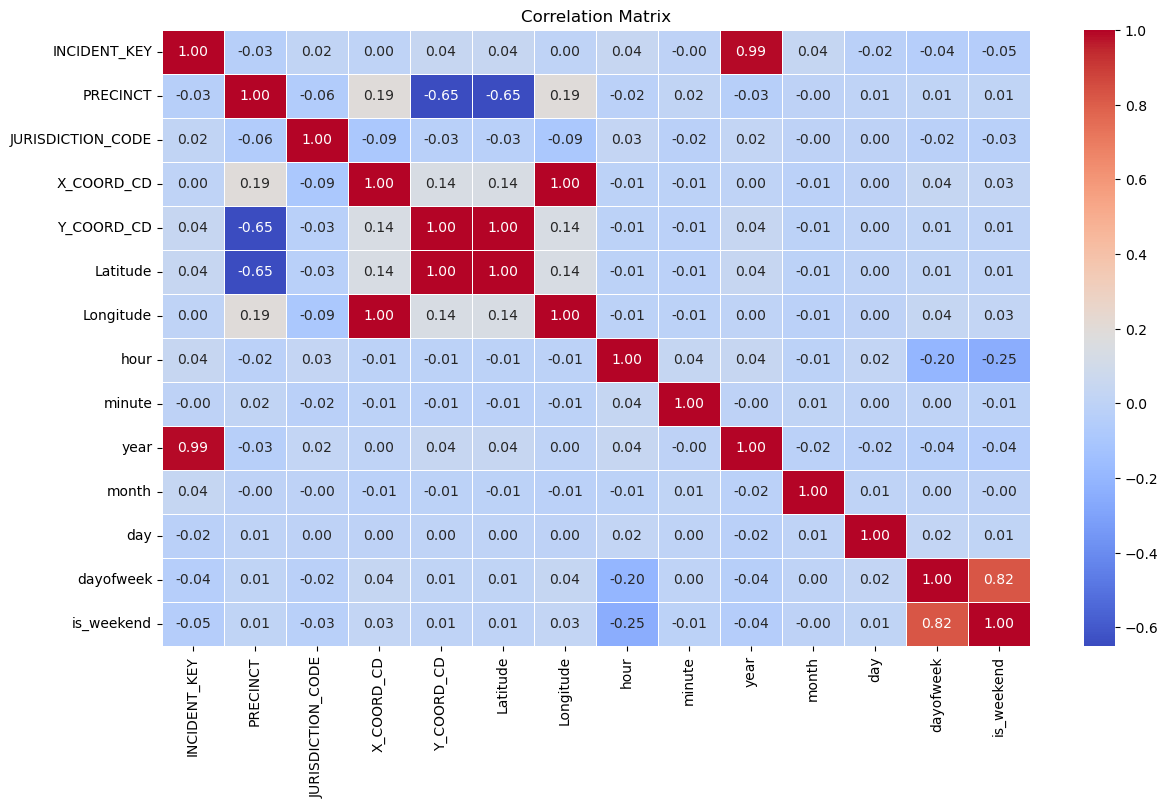

In [164]:
# Correlation Mtarix
df_matrix = df.select_dtypes(include='number')

plt.figure(figsize=(14, 8))

sns.heatmap(
    df_matrix.corr(),
    annot=True,
    fmt=".2f",          # show 2 decimal values
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

In [165]:
num_values = df.select_dtypes(include='number').columns
print(num_values)

Index(['INCIDENT_KEY', 'PRECINCT', 'JURISDICTION_CODE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'hour', 'minute', 'year',
       'month', 'day', 'dayofweek', 'is_weekend'],
      dtype='object')


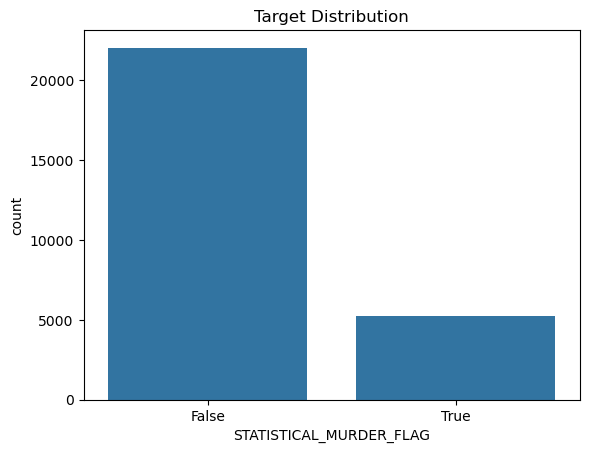

In [166]:
#Target Distribution

sns.countplot(data=df, x='STATISTICAL_MURDER_FLAG')
plt.title("Target Distribution")
plt.show()

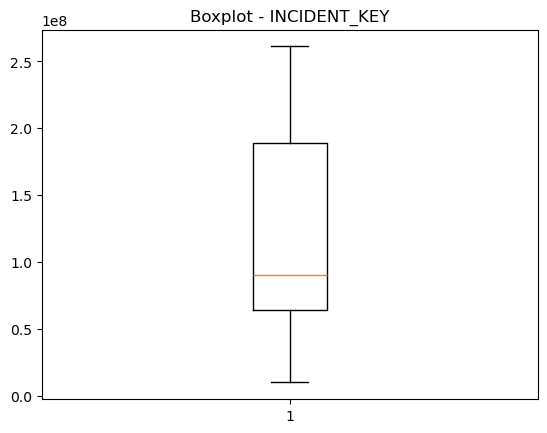

In [167]:
plt.figure()
plt.boxplot(df['INCIDENT_KEY'])
plt.title("Boxplot - INCIDENT_KEY")
plt.show()

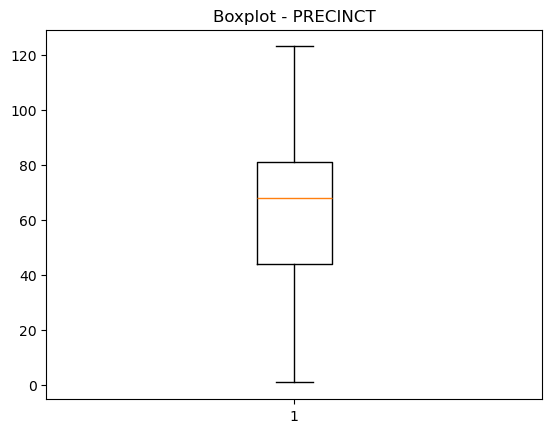

In [168]:
plt.figure()
plt.boxplot(df['PRECINCT'])
plt.title("Boxplot - PRECINCT")
plt.show()

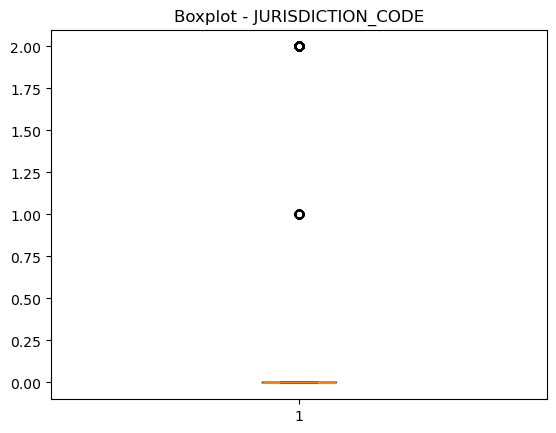

In [169]:
plt.figure()
plt.boxplot(df['JURISDICTION_CODE'])
plt.title("Boxplot - JURISDICTION_CODE")
plt.show()

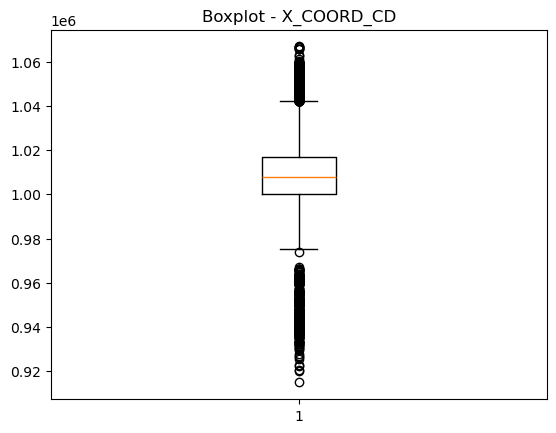

In [170]:
plt.figure()
plt.boxplot(df['X_COORD_CD'])
plt.title("Boxplot - X_COORD_CD")
plt.show()

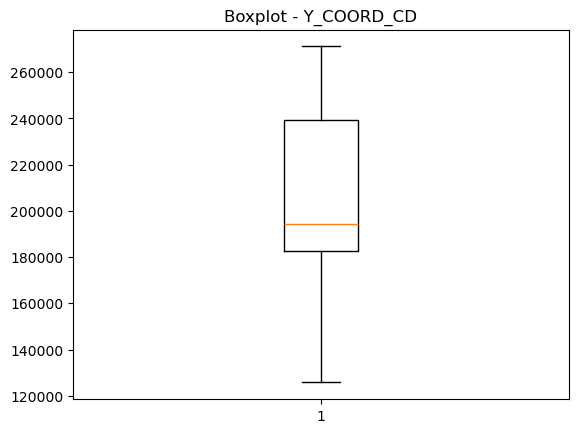

In [171]:
plt.figure()
plt.boxplot(df['Y_COORD_CD'])
plt.title("Boxplot - Y_COORD_CD")
plt.show()

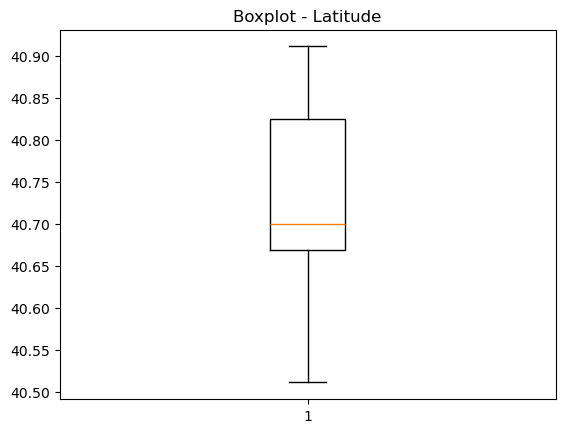

In [172]:
plt.figure()
plt.boxplot(df['Latitude'])
plt.title("Boxplot - Latitude")
plt.show()

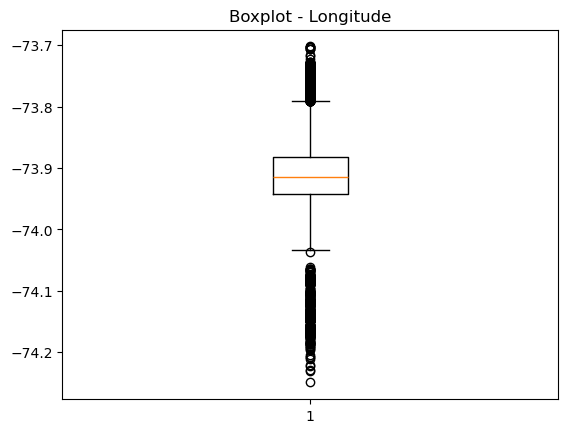

In [173]:
plt.figure()
plt.boxplot(df['Longitude'])
plt.title("Boxplot - Longitude")
plt.show()

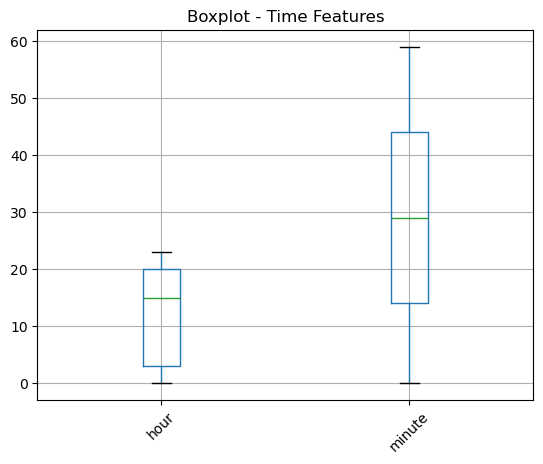

In [174]:
cols = ['hour', 'minute']

df[cols].boxplot()
plt.title("Boxplot - Time Features")
plt.xticks(rotation=45)
plt.show()

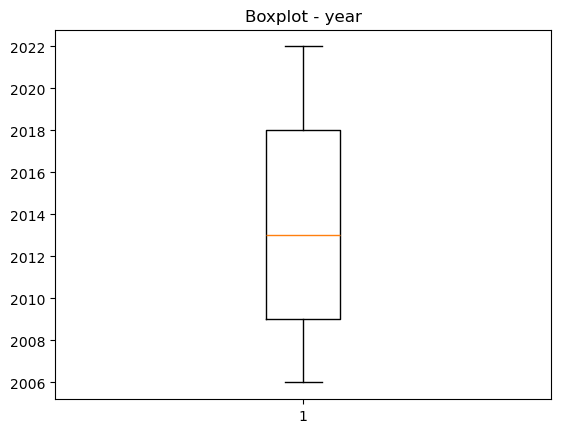

In [175]:
plt.figure()
plt.boxplot(df['year'])
plt.title("Boxplot - year")
plt.show()

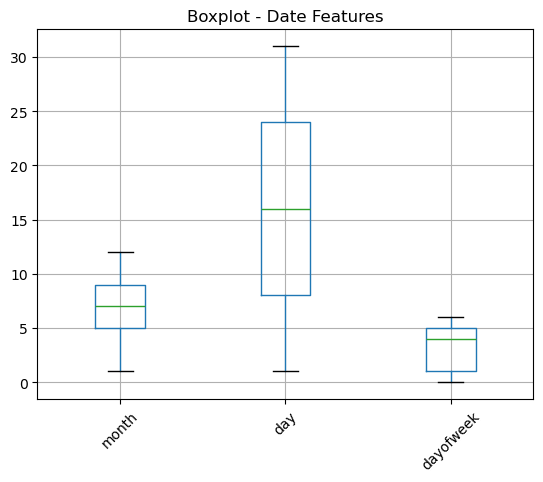

In [176]:
cols = ['month', 'day', 'dayofweek']

df[cols].boxplot()
plt.title("Boxplot - Date Features")
plt.xticks(rotation=45)
plt.show()

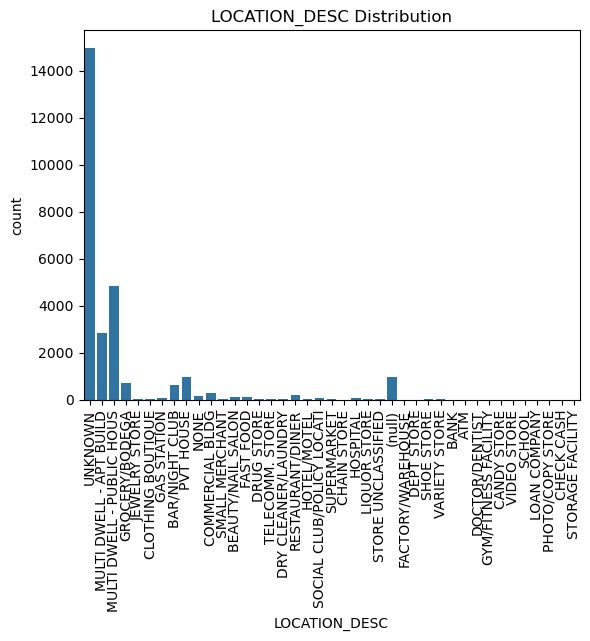

In [177]:
sns.countplot(data=df, x='LOCATION_DESC')
plt.xticks(rotation=90)
plt.title("LOCATION_DESC Distribution")
plt.show()

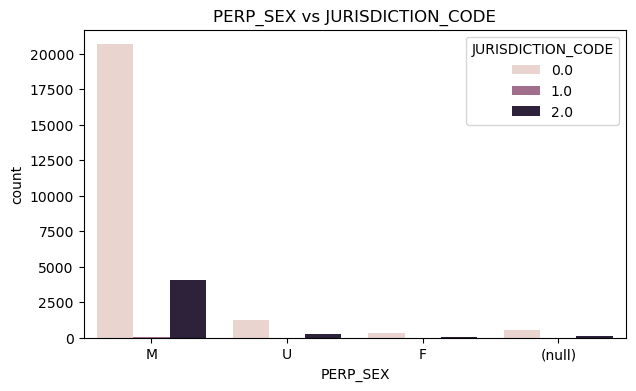

In [178]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='PERP_SEX', hue='JURISDICTION_CODE')
plt.title("PERP_SEX vs JURISDICTION_CODE")
plt.show()

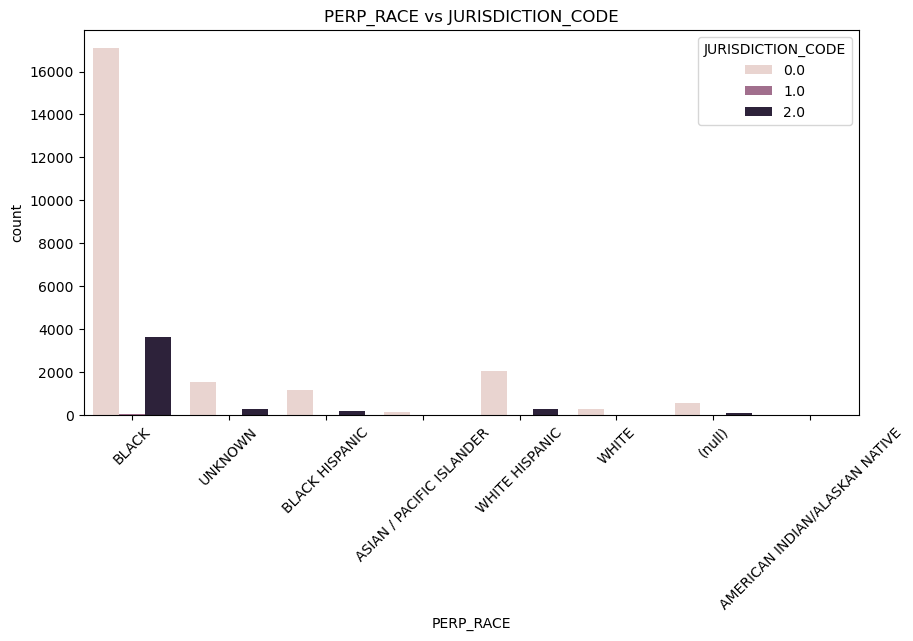

In [179]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PERP_RACE', hue='JURISDICTION_CODE')
plt.xticks(rotation=45)
plt.title("PERP_RACE vs JURISDICTION_CODE")
plt.show()

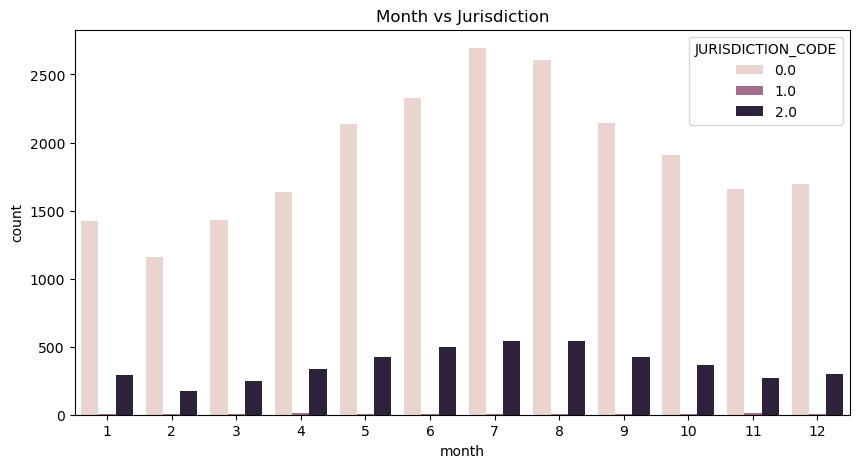

In [180]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='month', hue='JURISDICTION_CODE')
plt.title("Month vs Jurisdiction")
plt.show()

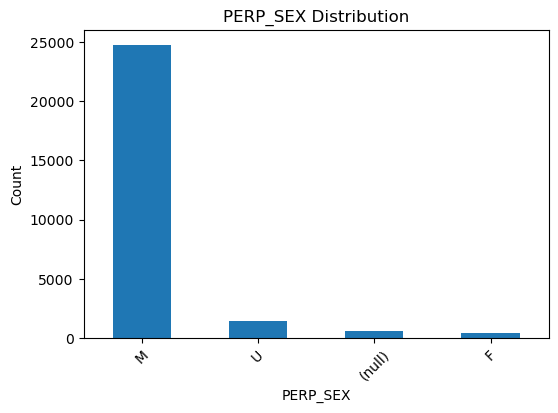

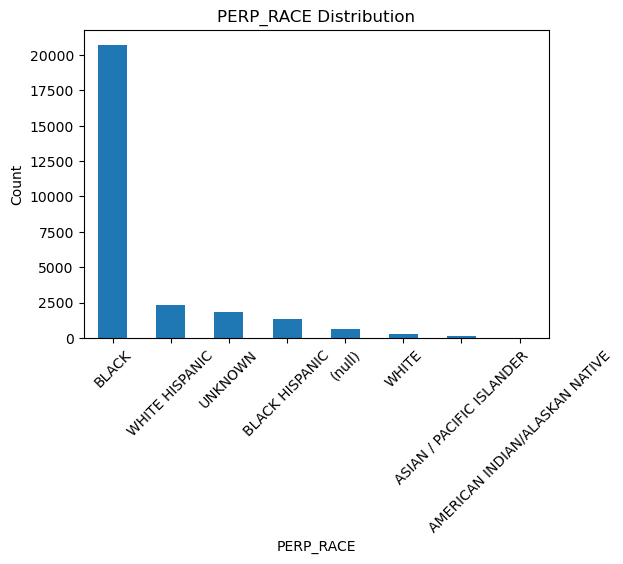

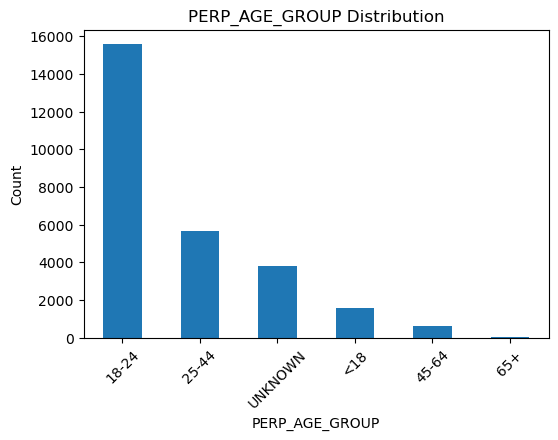

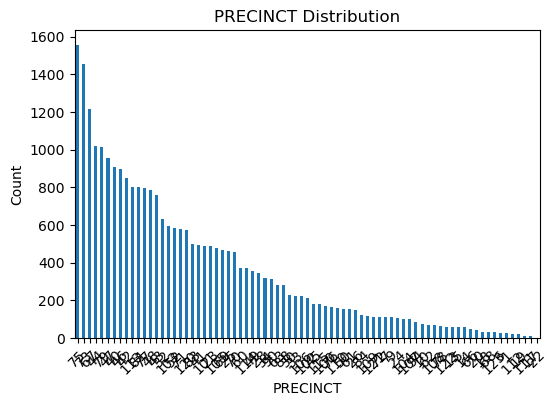

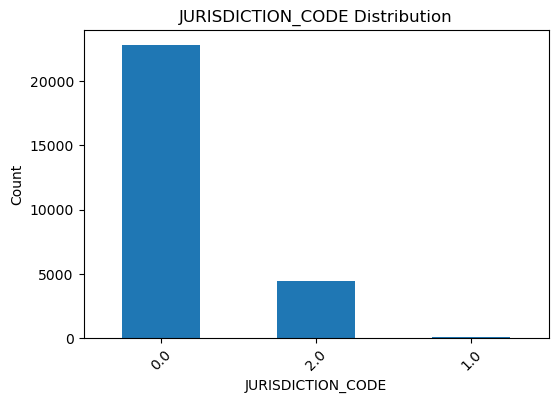

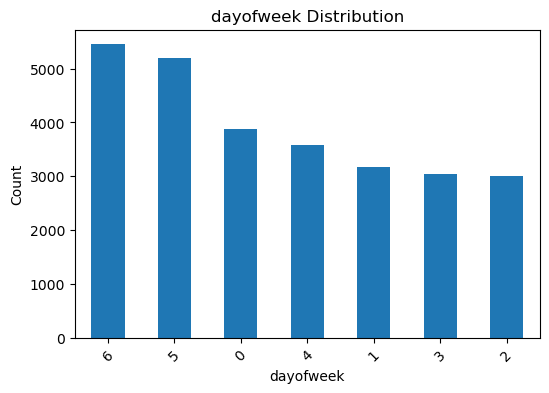

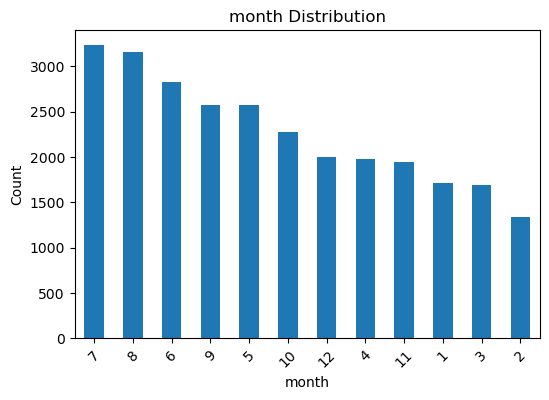

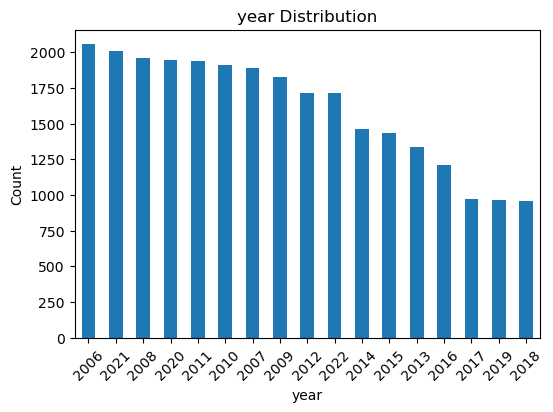

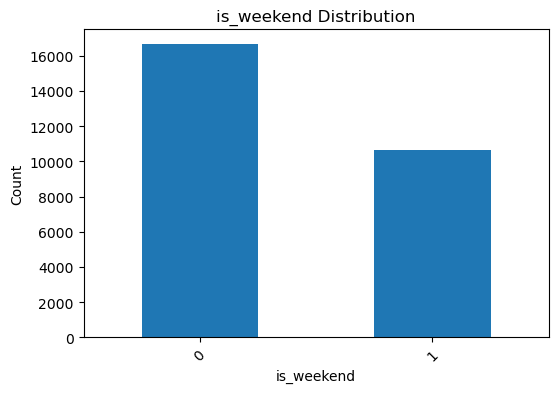

In [181]:
cols = ['PERP_SEX', 'PERP_RACE', 'PERP_AGE_GROUP', 
        'PRECINCT', 'JURISDICTION_CODE', 
        'dayofweek', 'month','year','is_weekend']

for col in cols:
    plt.figure(figsize=(6,4))
    
    df[col].value_counts().plot(kind='bar')
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45)
    plt.show()

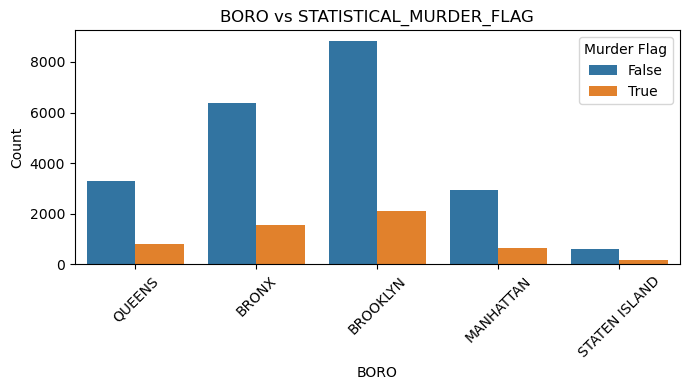

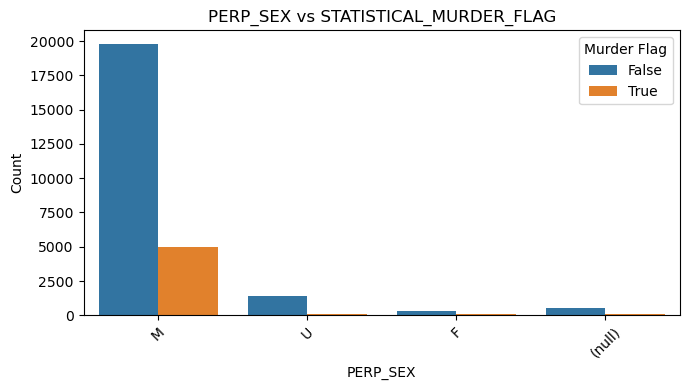

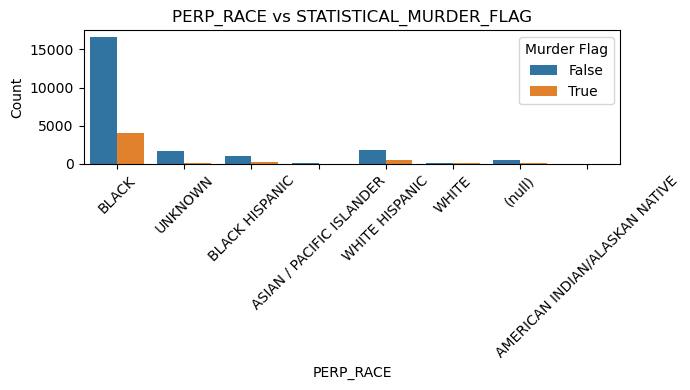

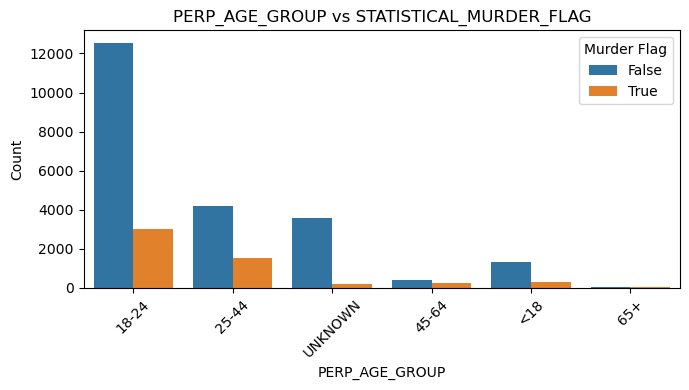

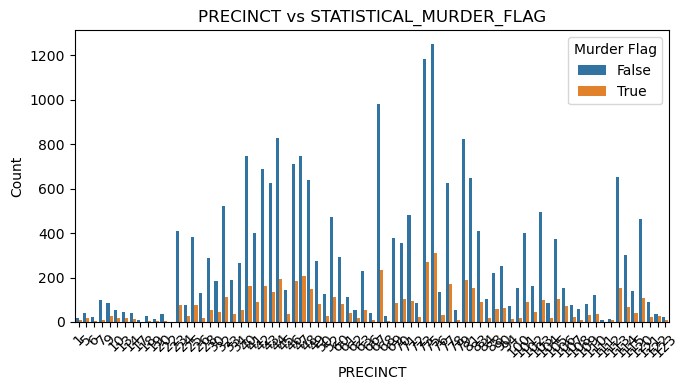

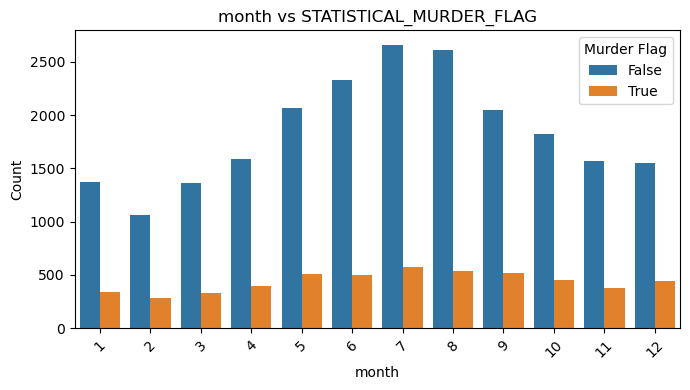

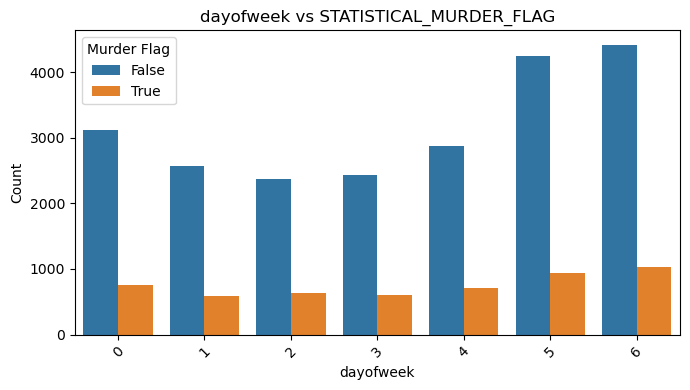

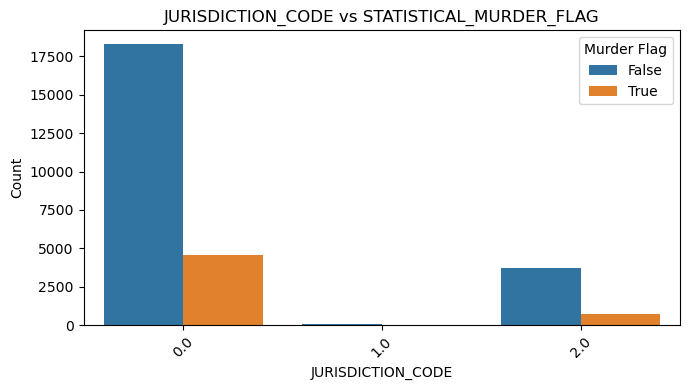

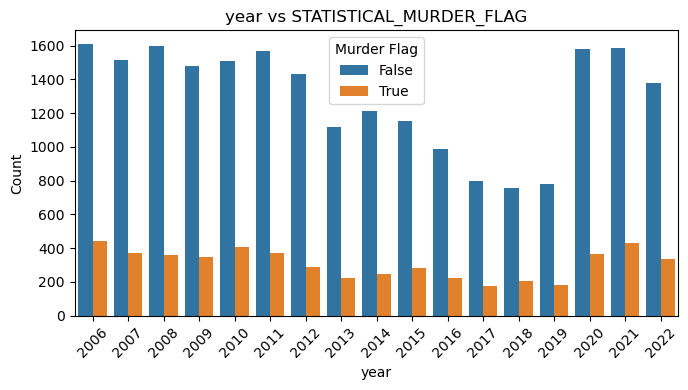

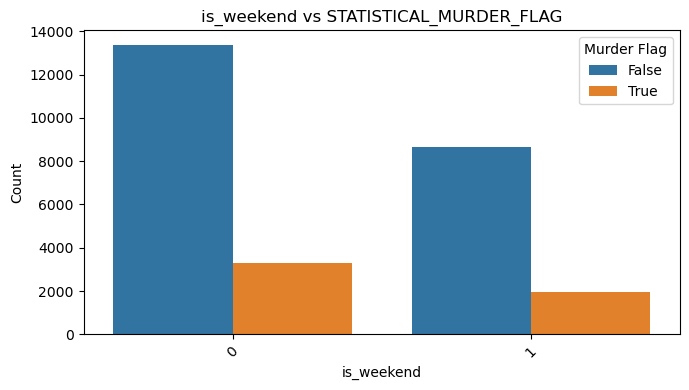

In [182]:
cols = ['BORO', 'PERP_SEX', 'PERP_RACE', 'PERP_AGE_GROUP', 'PRECINCT', 'month', 'dayofweek','JURISDICTION_CODE','year', 'is_weekend' ]

for col in cols:
    plt.figure(figsize=(7,4))
    
    sns.countplot(data=df, x=col, hue='STATISTICAL_MURDER_FLAG')
    
    plt.title(f"{col} vs STATISTICAL_MURDER_FLAG")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45)
    plt.legend(title="Murder Flag")
    
    plt.tight_layout()
    plt.show()

In [183]:
#Data Preprocessing

In [184]:
# One-hot encoding
cat_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [185]:
X = df.drop(columns=['INCIDENT_KEY', 'STATISTICAL_MURDER_FLAG', 'OCCUR_DATE', 'OCCUR_TIME', 'X_COORD_CD', 'Y_COORD_CD'], axis=1)
y = df['STATISTICAL_MURDER_FLAG']

In [186]:
X.head()

,PRECINCT,JURISDICTION_CODE,Latitude,Longitude,hour,minute,year,month,day,dayofweek,...,VIC_AGE_GROUP_<18,VIC_AGE_GROUP_UNKNOWN,VIC_SEX_M,VIC_SEX_U,VIC_RACE_ASIAN / PACIFIC ISLANDER,VIC_RACE_BLACK,VIC_RACE_BLACK HISPANIC,VIC_RACE_UNKNOWN,VIC_RACE_WHITE,VIC_RACE_WHITE HISPANIC
0,105,0.0,40.662965,-73.730839,21,30,2021,5,27,3,...,False,False,True,False,False,True,False,False,False,False
1,40,0.0,40.810352,-73.924942,17,40,2014,6,27,4,...,False,False,True,False,False,True,False,False,False,False
2,108,0.0,40.742607,-73.915492,3,56,2015,11,21,5,...,False,False,True,False,False,False,False,False,True,False
3,44,0.0,40.837782,-73.919457,18,30,2015,10,9,4,...,True,False,True,False,False,False,False,False,False,True
4,47,0.0,40.886238,-73.852910,22,58,2009,2,19,3,...,False,False,True,False,False,True,False,False,False,False


In [187]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)


In [188]:
#Train And Test Split

In [189]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (21849, 84)
Testing data: (5463, 84)


In [190]:
# Convert ALL columns to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Fill missing values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [191]:
print(X_train.shape)
print(X_train.dtypes.head())
print(X_train.dtypes.unique())

(21849, 84)
PRECINCT               int64
JURISDICTION_CODE    float64
Latitude             float64
Longitude            float64
hour                   int32
dtype: object
[dtype('int64') dtype('float64') dtype('int32') dtype('bool')]


In [192]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [193]:
# Feature Scaling

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [194]:
X_train.head()

,PRECINCT,JURISDICTION_CODE,Latitude,Longitude,hour,minute,year,month,day,dayofweek,...,VIC_AGE_GROUP_<18,VIC_AGE_GROUP_UNKNOWN,VIC_SEX_M,VIC_SEX_U,VIC_RACE_ASIAN / PACIFIC ISLANDER,VIC_RACE_BLACK,VIC_RACE_BLACK HISPANIC,VIC_RACE_UNKNOWN,VIC_RACE_WHITE,VIC_RACE_WHITE HISPANIC
1847,60,0.0,40.575085,-73.961035,17,22,2011,6,9,3,...,False,False,True,False,False,False,False,False,True,False
15214,48,0.0,40.854257,-73.893986,2,15,2016,6,23,3,...,False,False,True,False,False,False,False,False,False,True
2188,23,0.0,40.794141,-73.942805,13,55,2011,12,31,5,...,False,False,True,False,False,False,False,False,True,False
13115,73,2.0,40.670139,-73.908925,21,2,2020,6,17,2,...,False,False,True,False,False,True,False,False,False,False
16547,70,0.0,40.641940,-73.958408,22,20,2007,7,30,0,...,False,False,False,False,False,True,False,False,False,False


In [195]:
#Model Selection 

In [196]:
# Model 1:
log_model = LogisticRegression(max_iter=3000, solver='liblinear',class_weight='balanced')
log_model.fit(X_scaled_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, solver='liblinear')

In [197]:
# Prediction
y_pred = log_model.predict(X_scaled_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.6115687351272194

Report:
               precision    recall  f1-score   support

       False       0.87      0.61      0.72      4431
        True       0.27      0.62      0.38      1032

    accuracy                           0.61      5463
   macro avg       0.57      0.62      0.55      5463
weighted avg       0.76      0.61      0.65      5463


Confusion Matrix:
 [[2696 1735]
 [ 387  645]]


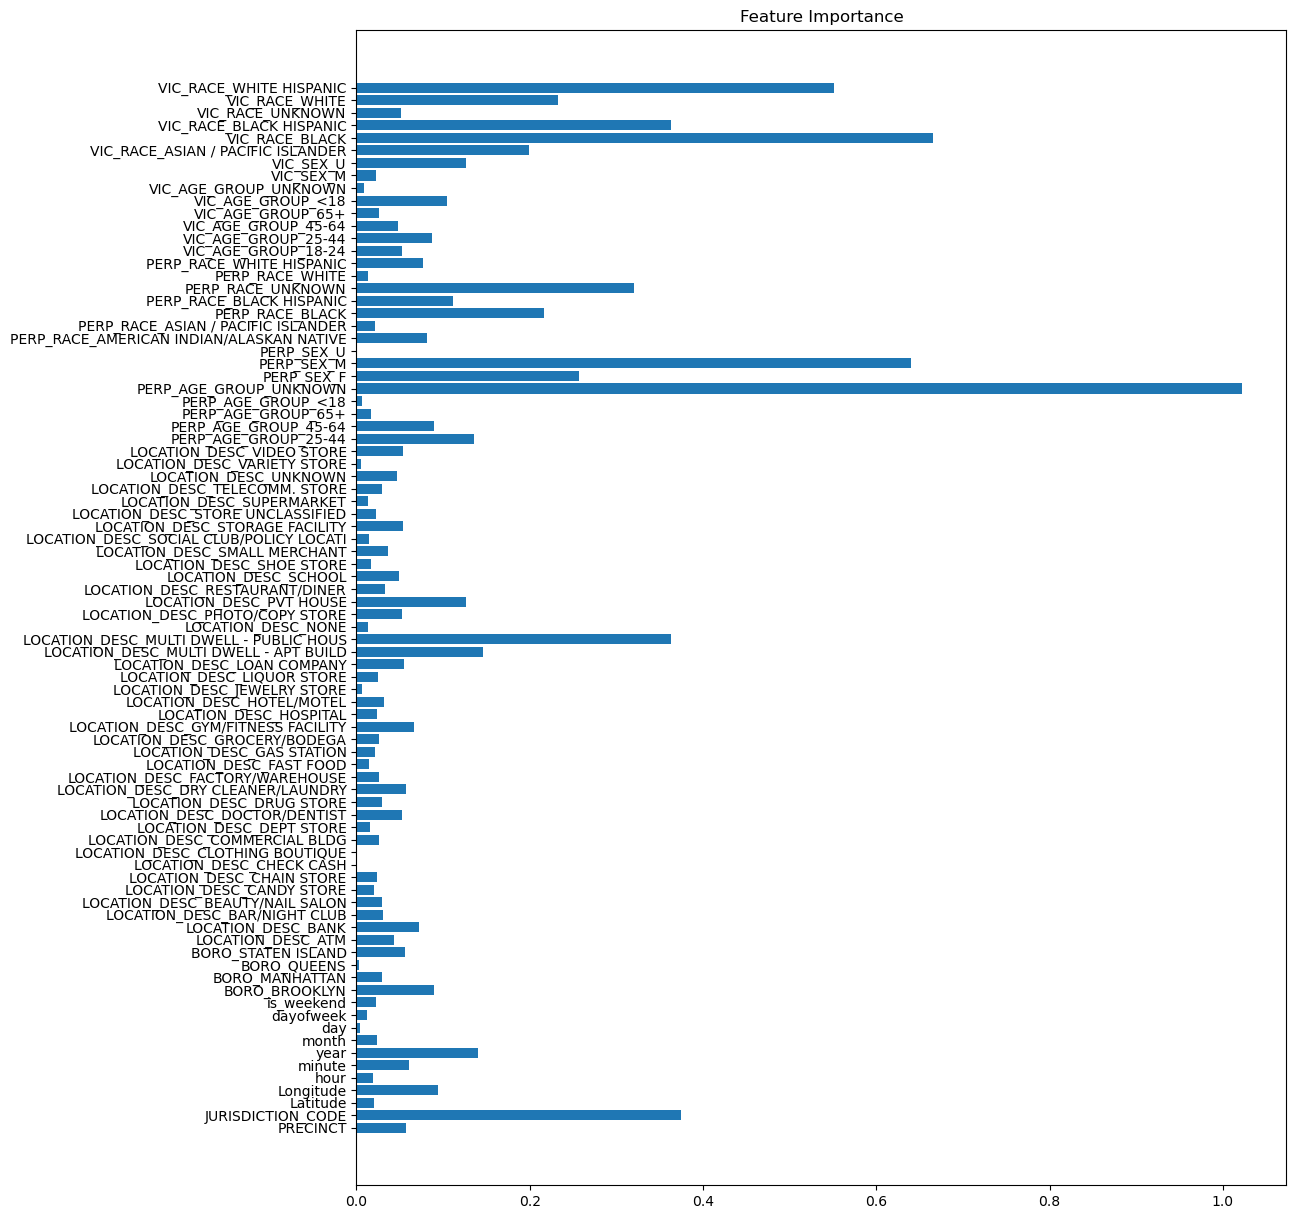

In [198]:
# Feature Importance
plt.figure(figsize=(12,15))
plt.barh(X.columns, abs(log_model.coef_[0]))
plt.title("Feature Importance")
plt.show()

In [199]:
#model 2:
dc_model = DecisionTreeClassifier(max_depth=10)
dc_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [200]:
#Prediction
y_pred = dc_model.predict(X_test)

#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy : 0.8024894746476295

Report:
               precision    recall  f1-score   support

       False       0.82      0.97      0.89      4431
        True       0.40      0.09      0.14      1032

    accuracy                           0.80      5463
   macro avg       0.61      0.53      0.52      5463
weighted avg       0.74      0.80      0.75      5463


Confusion Matrix:
 [[4293  138]
 [ 941   91]]


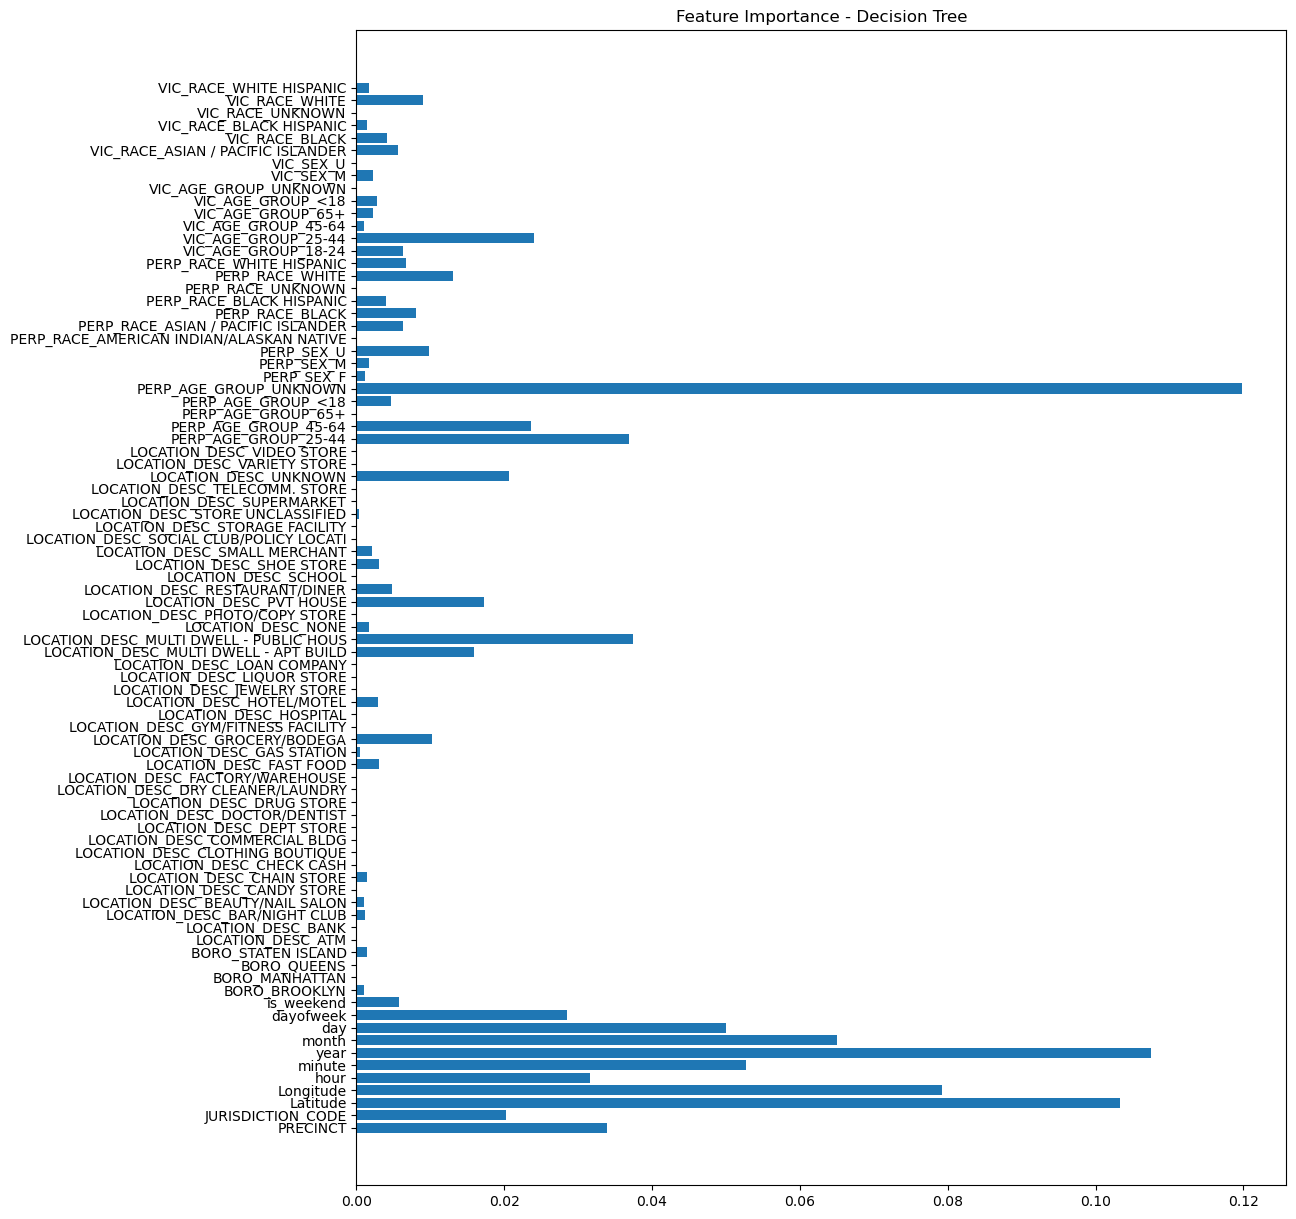

In [201]:
# Feature Importance
plt.figure(figsize=(12,15))
plt.barh(X.columns, dc_model.feature_importances_)
plt.title("Feature Importance - Decision Tree")
plt.show()

In [202]:
#Model 3:
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1)

In [203]:
#Prediction
y_pred = rf_model.predict(X_test)

#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy : 0.7788760754164379

Report:
               precision    recall  f1-score   support

       False       0.81      0.95      0.87      4431
        True       0.22      0.06      0.10      1032

    accuracy                           0.78      5463
   macro avg       0.51      0.51      0.49      5463
weighted avg       0.70      0.78      0.73      5463


Confusion Matrix:
 [[4188  243]
 [ 965   67]]


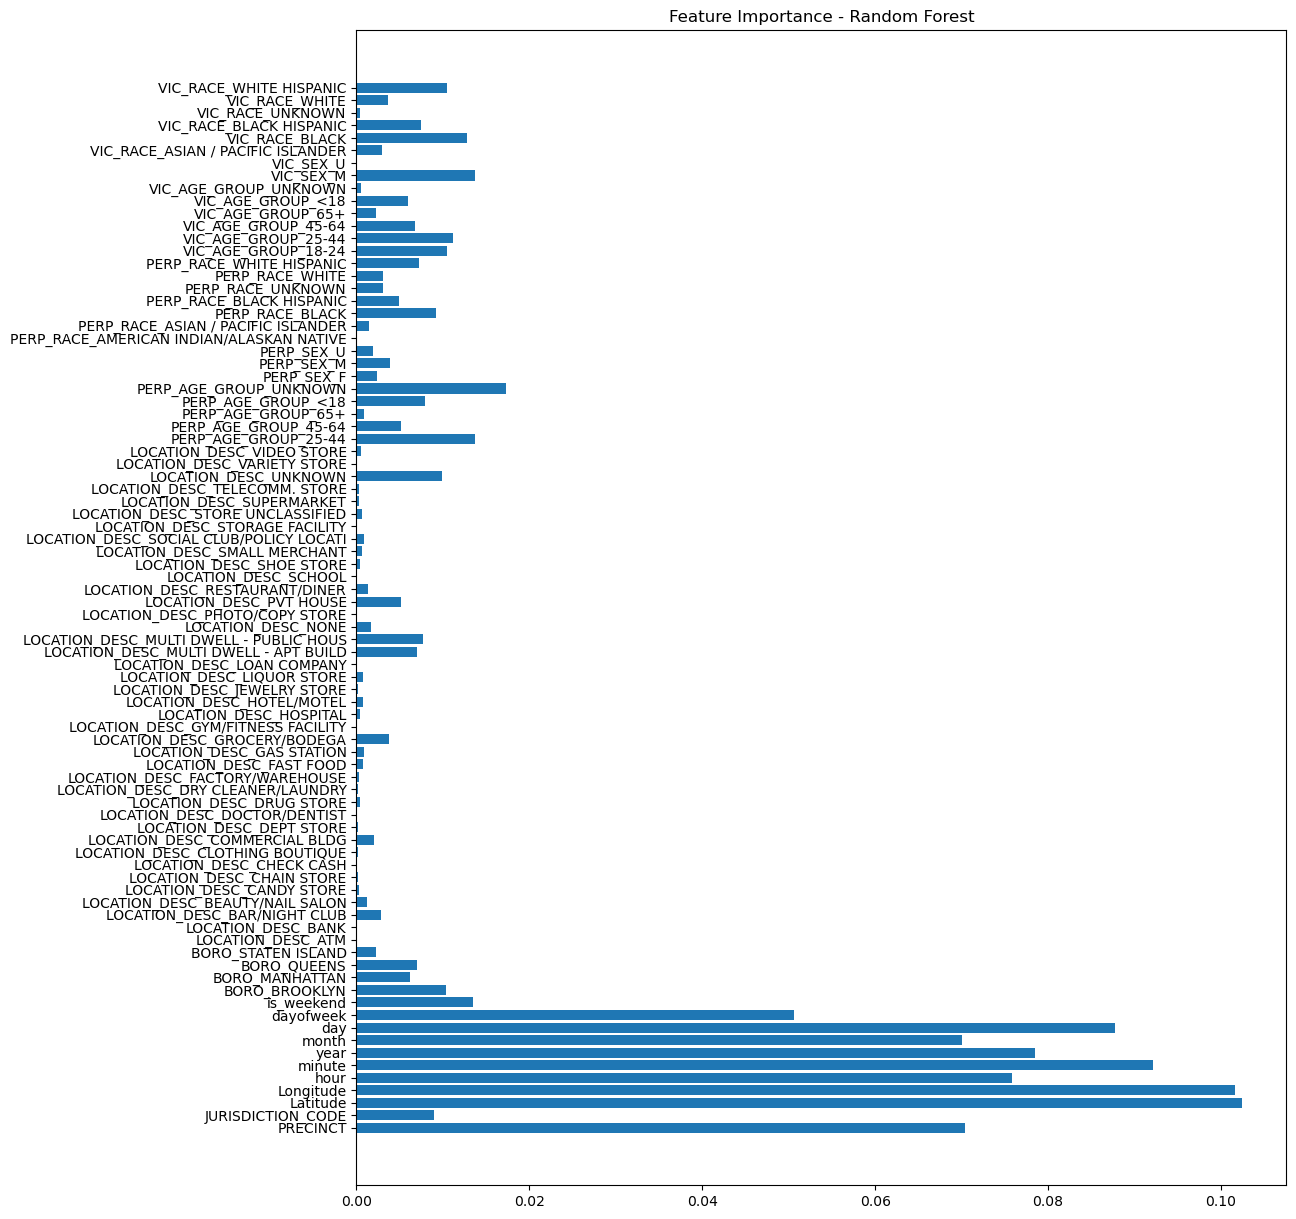

In [204]:
# Feature Importance
plt.figure(figsize=(12,15))
plt.barh(X.columns, rf_model.feature_importances_)
plt.title("Feature Importance - Random Forest")
plt.show()

In [205]:
#Model 4:
gb_model = GradientBoostingClassifier(n_estimators=100)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [206]:
#Prediction
y_pred = gb_model.predict(X_test)

#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy : 0.8110928061504667

Report:
               precision    recall  f1-score   support

       False       0.81      1.00      0.90      4431
        True       0.50      0.02      0.04      1032

    accuracy                           0.81      5463
   macro avg       0.66      0.51      0.47      5463
weighted avg       0.75      0.81      0.73      5463


Confusion Matrix:
 [[4411   20]
 [1012   20]]


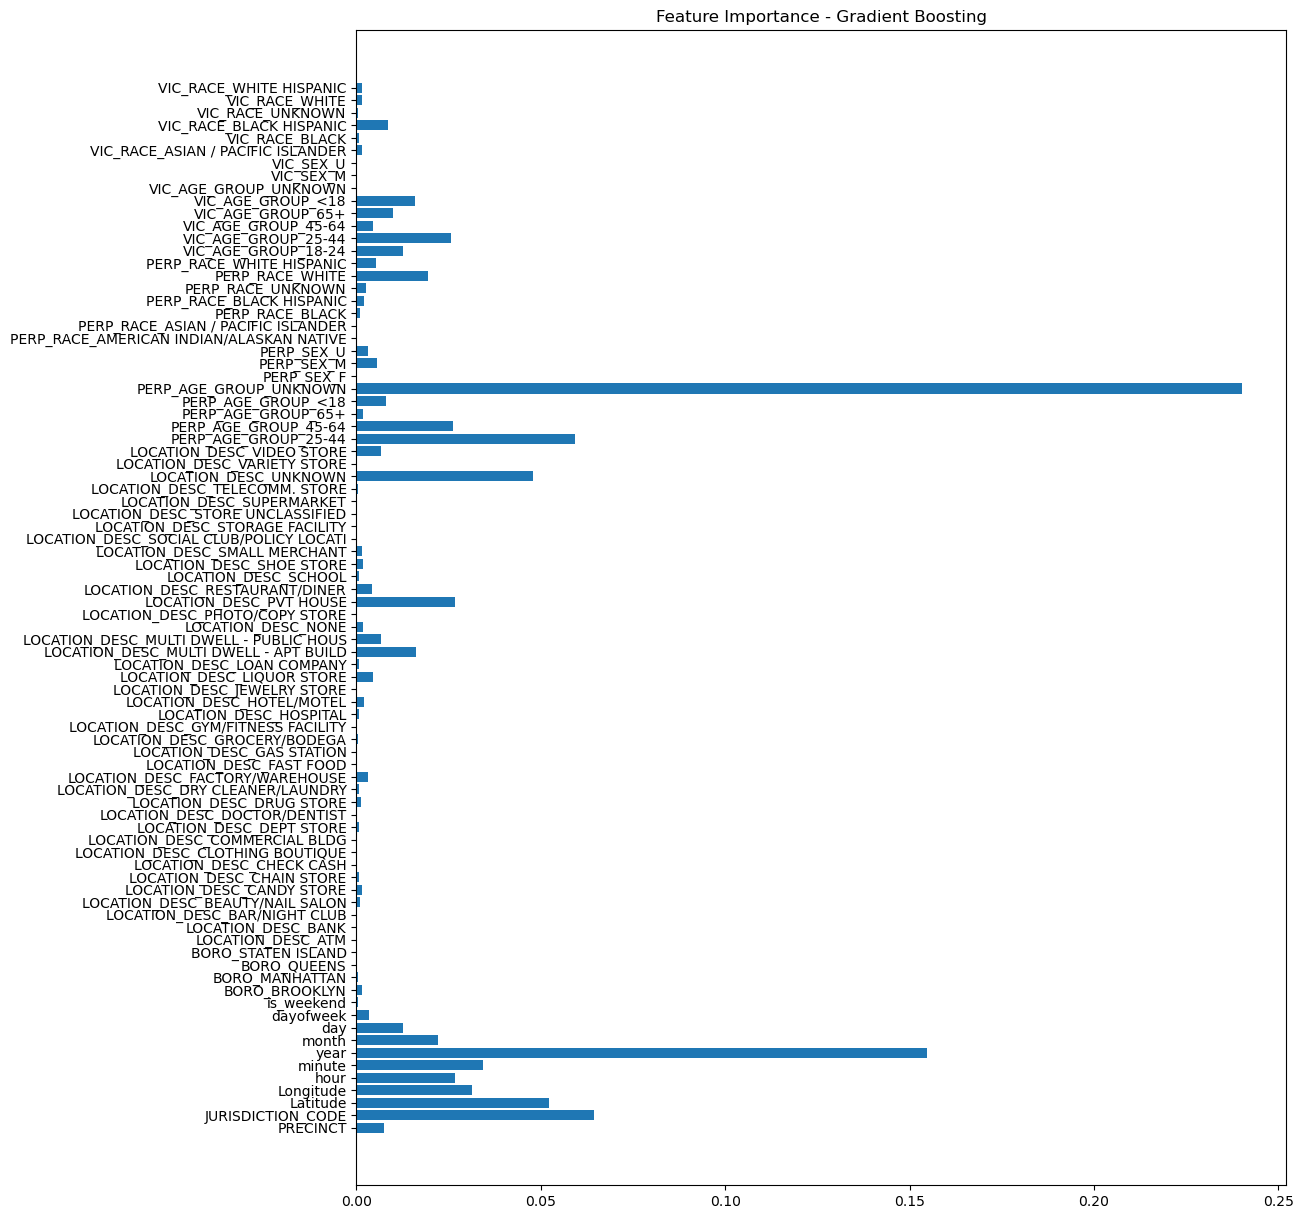

In [207]:
# Feature Importance
plt.figure(figsize=(12,15))
plt.barh(X.columns, gb_model.feature_importances_)
plt.title("Feature Importance - Gradient Boosting")
plt.show()

In [208]:
X_train.columns = (
    X_train.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('>', 'lt_', regex=False)
    .str.replace('<', 'gt_', regex=False)
    .str.replace(' ', '_')
)
X_test.columns = X_train.columns

In [209]:
#Model 5:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [210]:
#Prediction
y_pred = xgb_model.predict(X_test)

#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8083470620538166

Report:
               precision    recall  f1-score   support

       False       0.83      0.97      0.89      4431
        True       0.47      0.13      0.20      1032

    accuracy                           0.81      5463
   macro avg       0.65      0.55      0.55      5463
weighted avg       0.76      0.81      0.76      5463


Confusion Matrix:
 [[4284  147]
 [ 900  132]]


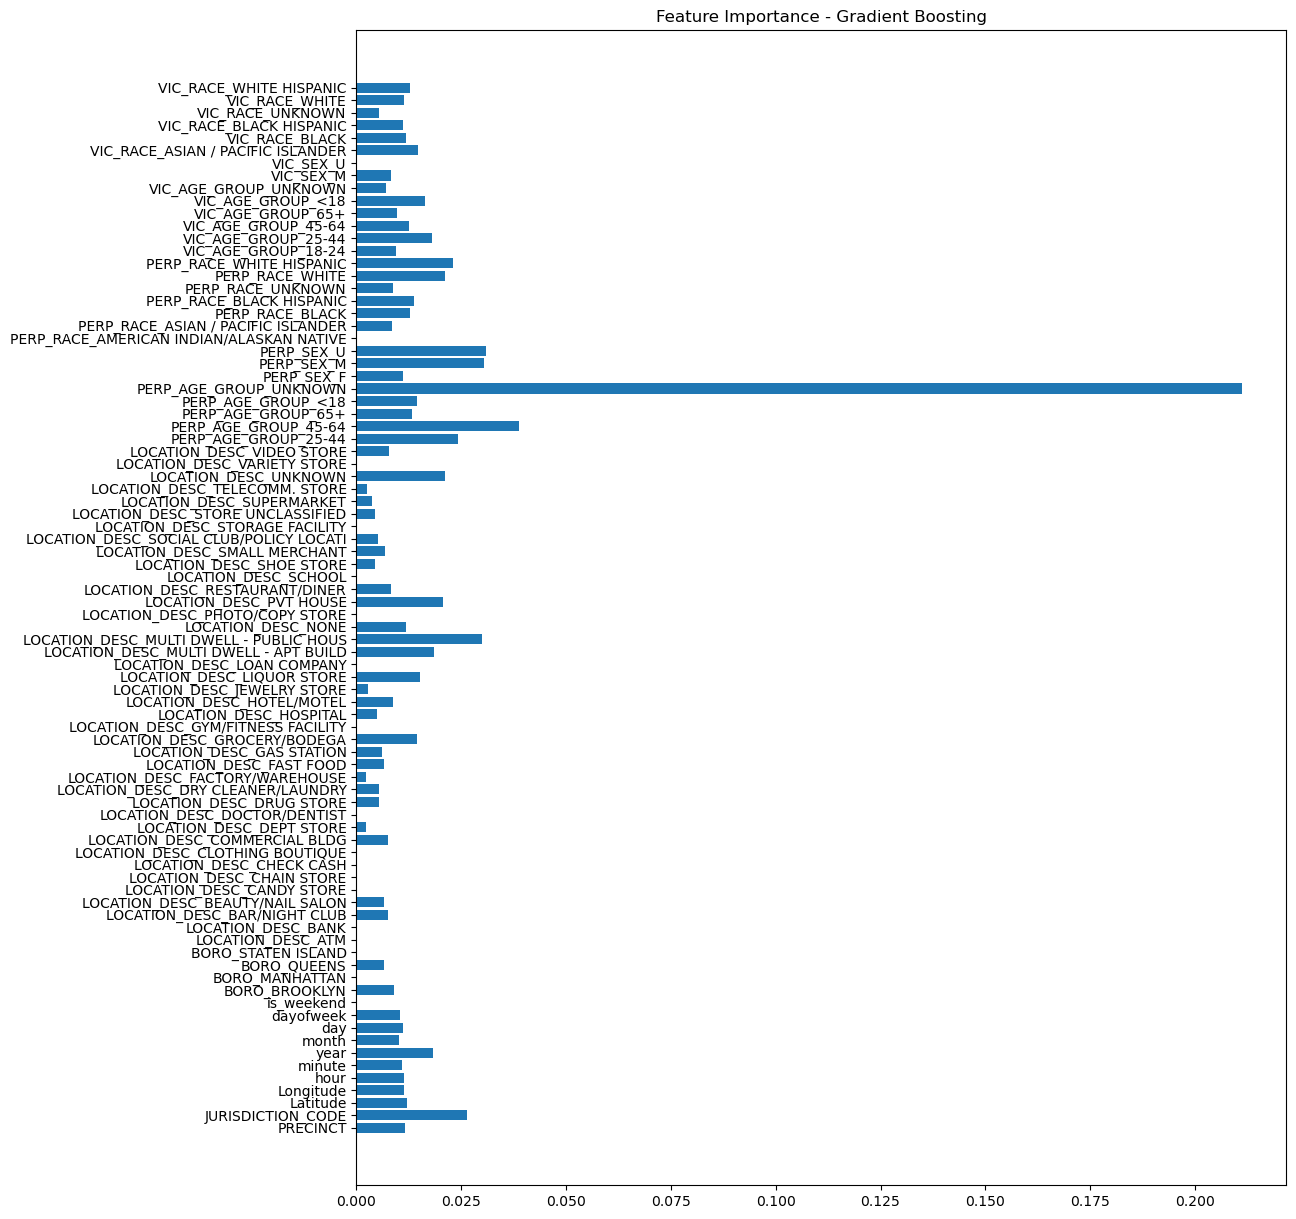

In [211]:
# Feature Importance
plt.figure(figsize=(12,15))
plt.barh(X.columns, xgb_model.feature_importances_)
plt.title("Feature Importance - Gradient Boosting")
plt.show()

In [212]:
#Model 6:
svm_model = LinearSVC(class_weight='balanced', max_iter=2000)
svm_model.fit(X_scaled_train, y_train)

LinearSVC(class_weight='balanced', max_iter=2000)

In [213]:
#Prediction
y_pred = svm_model.predict(X_scaled_test)

#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.6115687351272194

Report:
               precision    recall  f1-score   support

       False       0.88      0.61      0.72      4431
        True       0.27      0.63      0.38      1032

    accuracy                           0.61      5463
   macro avg       0.57      0.62      0.55      5463
weighted avg       0.76      0.61      0.65      5463


Confusion Matrix:
 [[2692 1739]
 [ 383  649]]


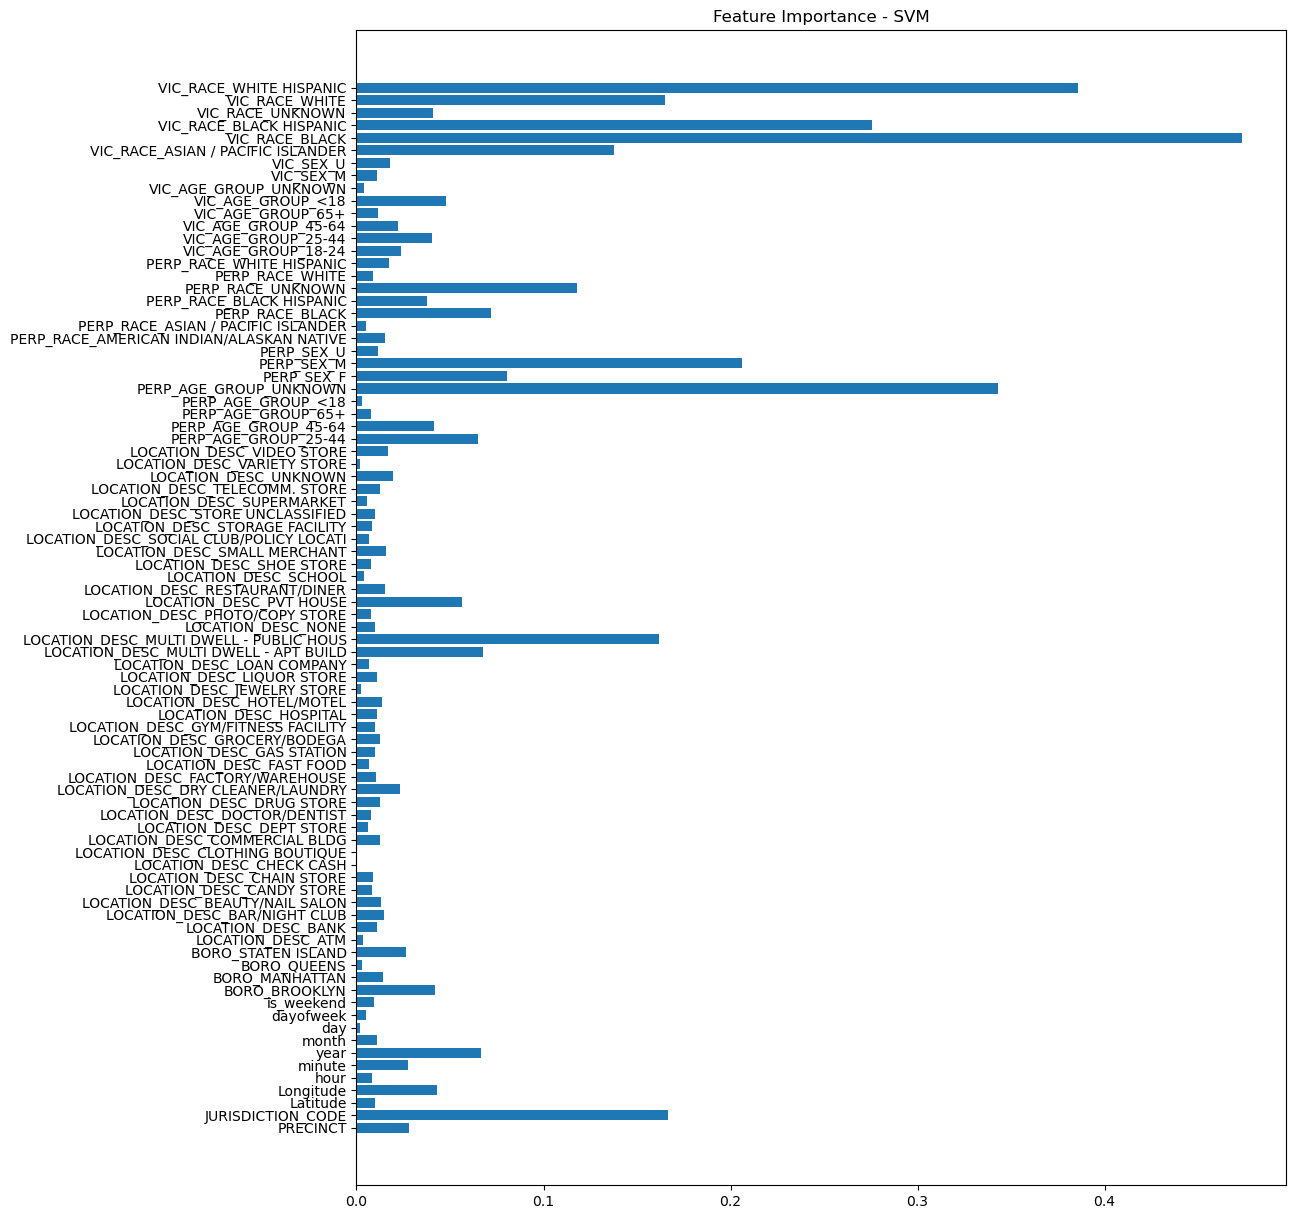

In [214]:
# Feature Importance
importances = abs(svm_model.coef_[0])

plt.figure(figsize=(12,15))
plt.barh(X.columns, importances)
plt.title("Feature Importance - SVM")
plt.show()

In [215]:
#Mdeol 7:

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_scaled_train, y_train)

KNeighborsClassifier()

In [216]:
#Prediction
y_pred = knn_model.predict(X_scaled_test)

#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.7786930258099946

Report:
               precision    recall  f1-score   support

       False       0.82      0.94      0.87      4431
        True       0.27      0.10      0.15      1032

    accuracy                           0.78      5463
   macro avg       0.54      0.52      0.51      5463
weighted avg       0.71      0.78      0.74      5463


Confusion Matrix:
 [[4150  281]
 [ 928  104]]


In [217]:
X_test_array = X_test.values

In [218]:
results = []

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dc_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
    "SVM": svm_model,
    "KNN": knn_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, f1])

In [219]:
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])

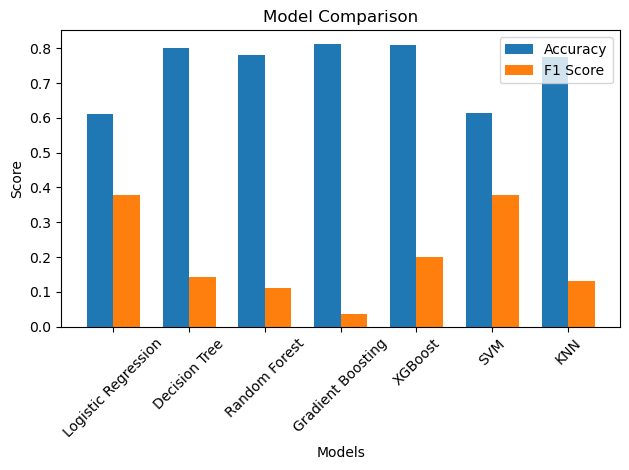

In [220]:
#Model Comparision
x = np.arange(len(df_results["Model"]))
width = 0.35

plt.figure()

plt.bar(x - width/2, df_results["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, df_results["F1 Score"], width, label="F1 Score")

plt.xticks(x, df_results["Model"], rotation=45)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison")

plt.legend()
plt.tight_layout()
plt.show()

In [221]:
#Hyperparameter Tuning
xgb = XGBClassifier(eval_metric='logloss')

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [222]:
best_xgb = grid.best_estimator_

In [223]:
#BEST MODEL
y_pred = best_xgb.predict(X_test.values)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.81      0.99      0.90      4431
        True       0.50      0.03      0.06      1032

    accuracy                           0.81      5463
   macro avg       0.66      0.51      0.48      5463
weighted avg       0.76      0.81      0.74      5463



In [224]:
from sklearn.metrics import roc_curve, auc

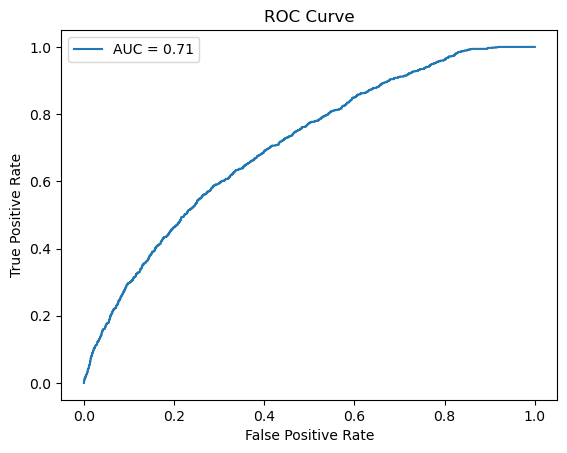

In [225]:
y_prob = best_xgb.predict_proba(X_test.values)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [226]:
df.to_csv("final_processed_data.csv", index=False)
print('final_processed_data saved successfully!')

final_processed_data saved successfully!


In [227]:
joblib.dump(best_xgb, "final_xgboost_model.pkl")
print("Best model saved as best_model.pkl")

Best model saved as best_model.pkl
